# **Gathering Data**
[Data source]https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset/data

In [1]:
#1. IMPORTING LIBRARIES & PACKAGES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , f1_score , classification_report

In [10]:
#title Read data into Data-frame
df  = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **EDA**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
_sum = (df==0).sum()
print(_sum)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


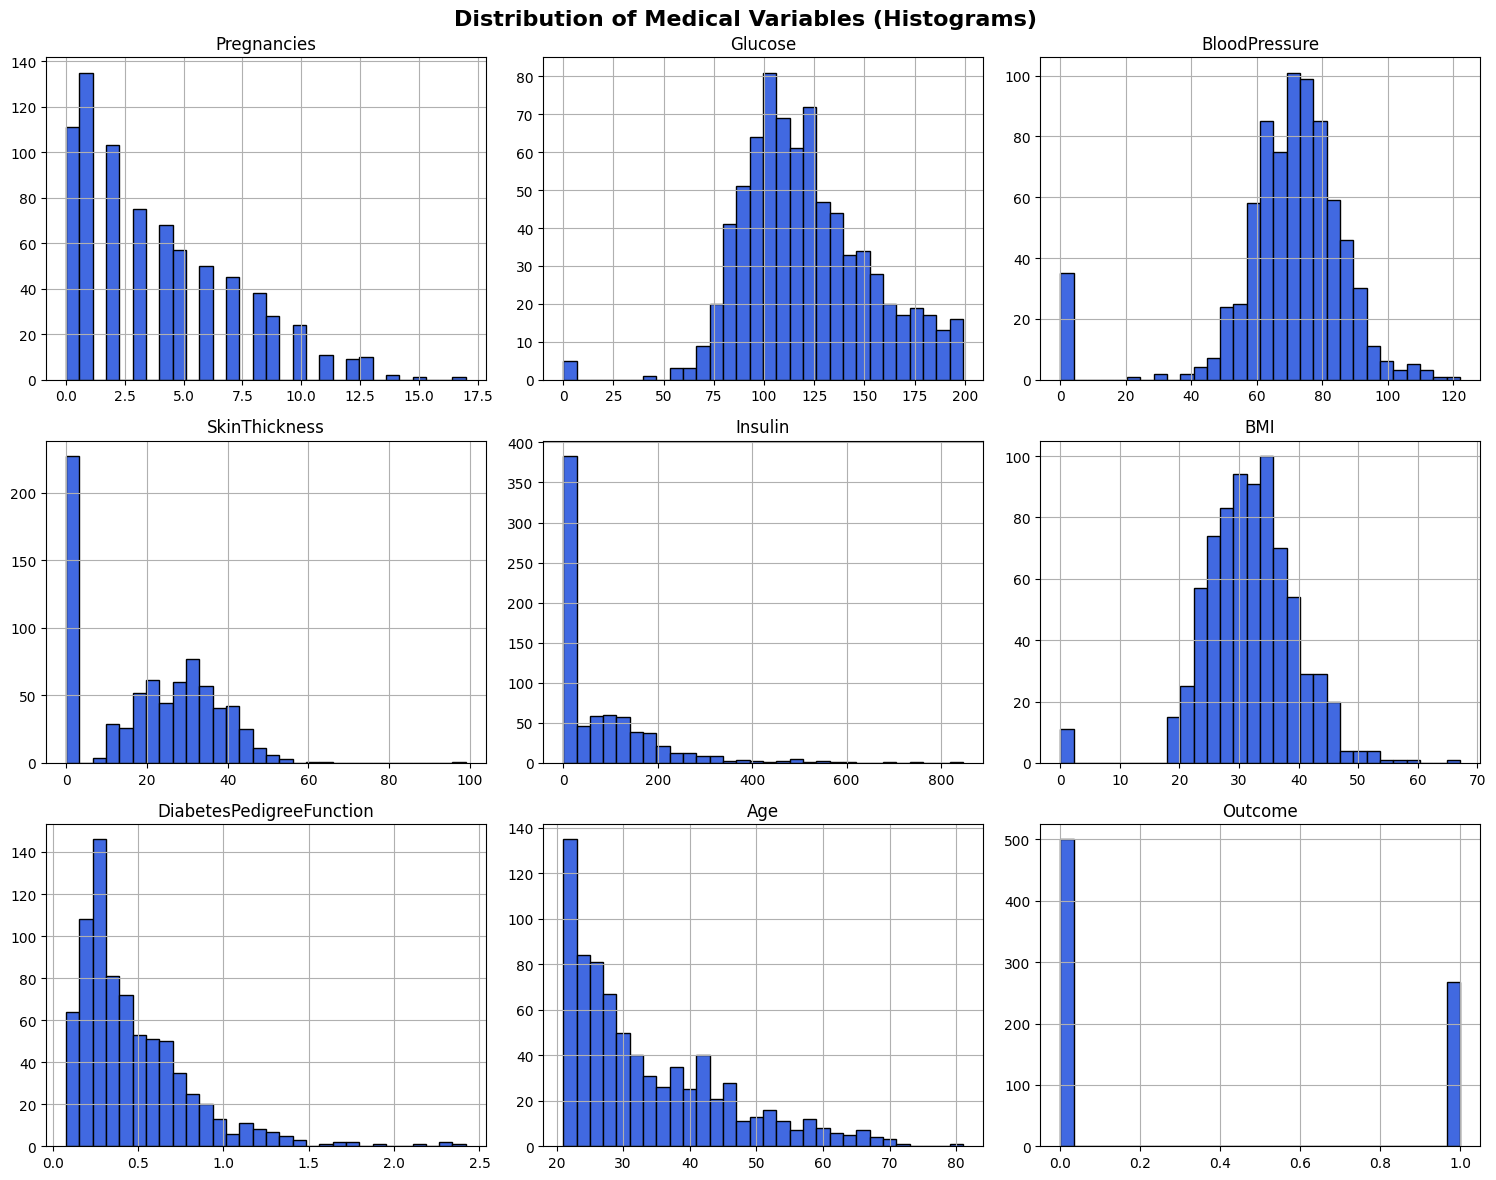

In [15]:
# Plot histograms for all features to understand distributions and identify zeros
df.hist(bins=30, figsize=(15, 12), color='royalblue', edgecolor='black')
plt.suptitle('Distribution of Medical Variables (Histograms)', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

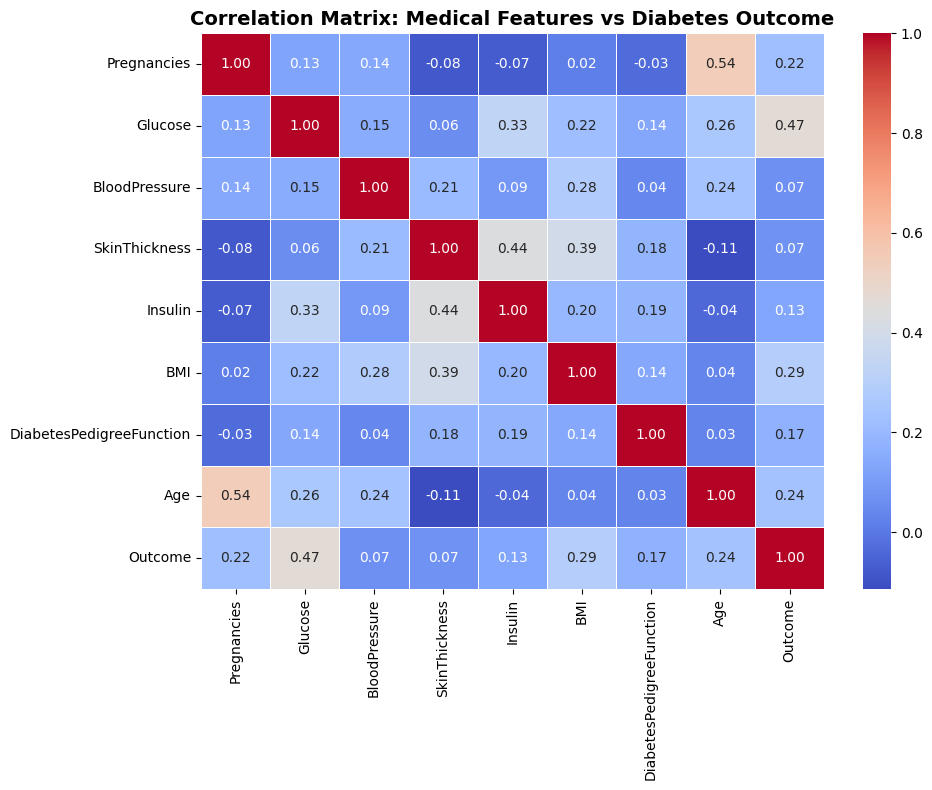

In [16]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Medical Features vs Diabetes Outcome', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

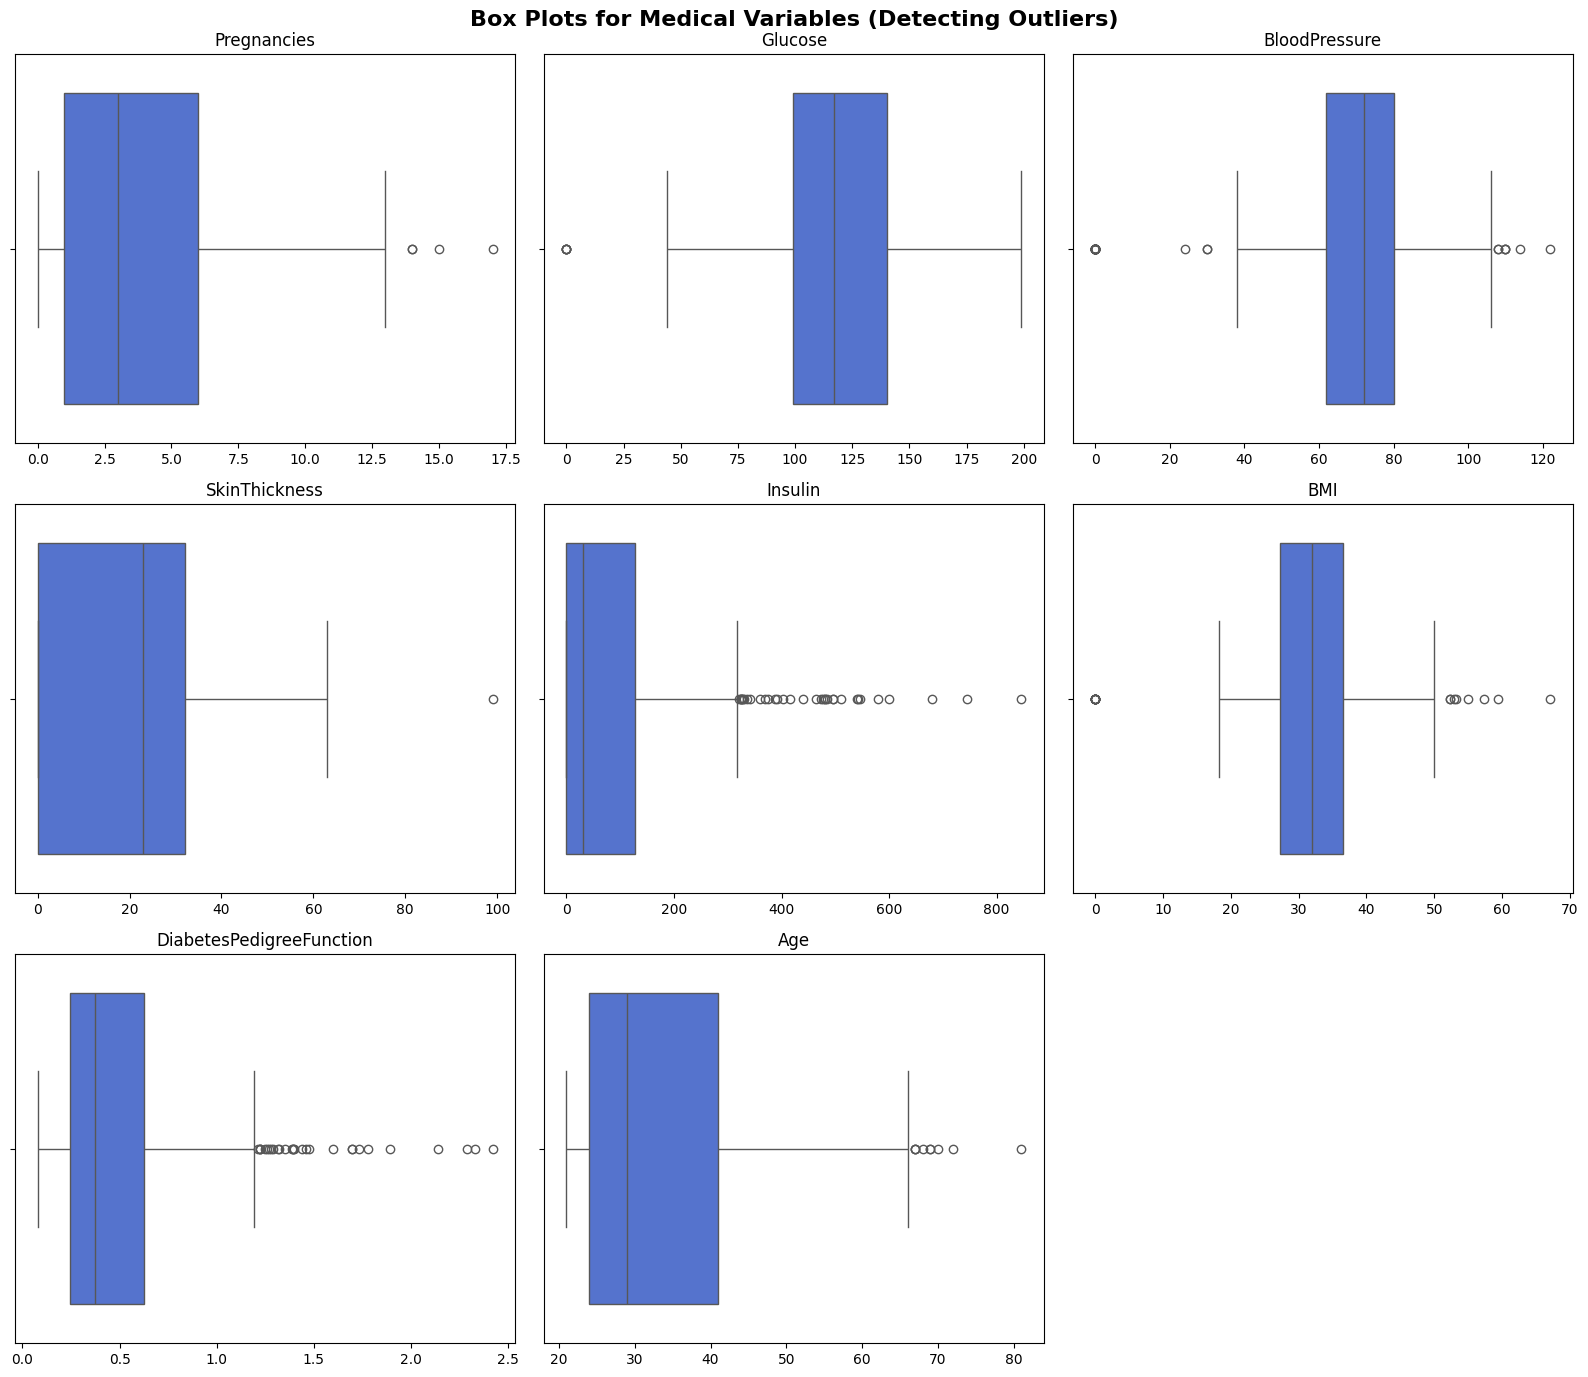

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Box Plots for Medical Variables (Detecting Outliers)', fontsize=16, fontweight='bold')

axes = axes.flatten()

features = [col for col in df.columns if col != 'Outcome']


for i, col in enumerate(features):
    sns.boxplot(data=df, x=col, ax=axes[i], color='royalblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

axes[-1].axis('off')

plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [18]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

df[cols_with_zero] = df[cols_with_zero].fillna(df[cols_with_zero].median())

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [19]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


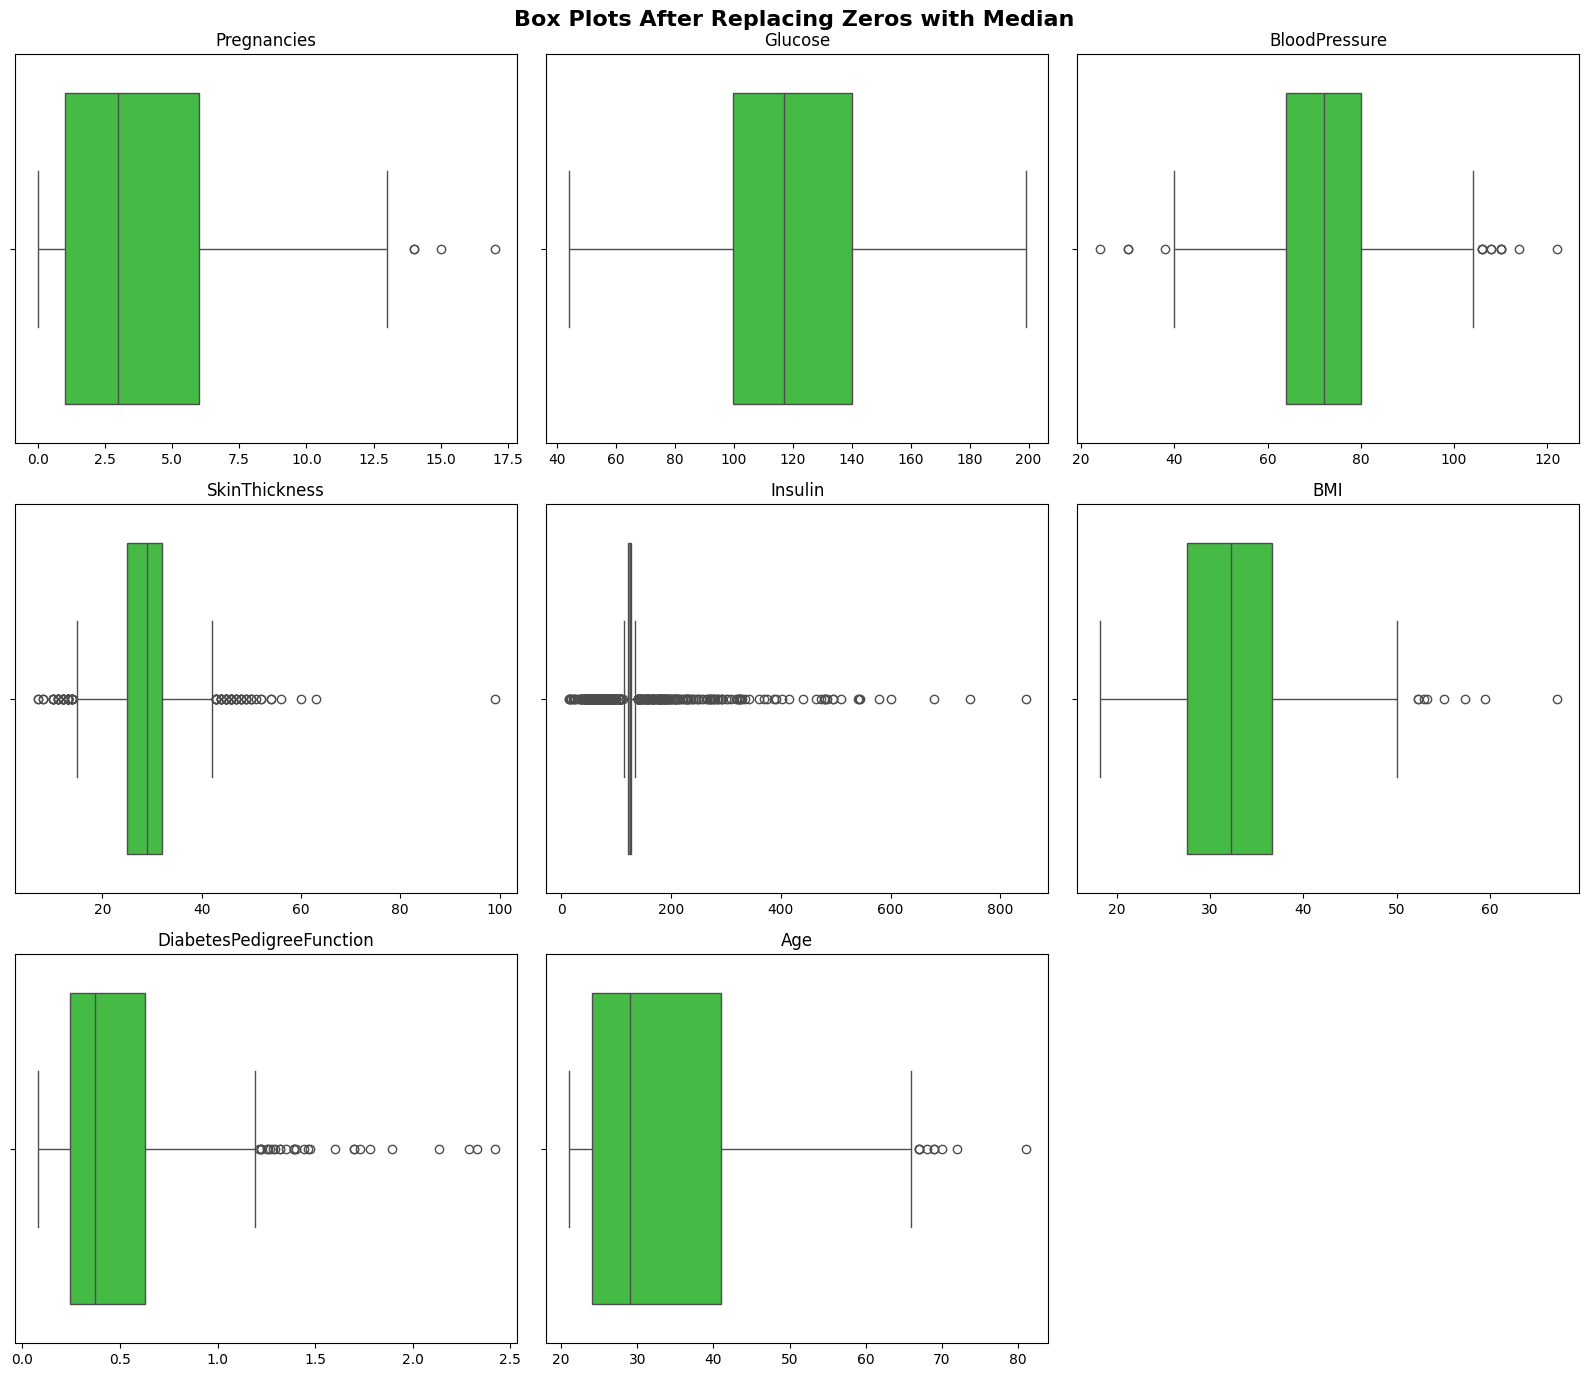

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Box Plots After Replacing Zeros with Median', fontsize=16, fontweight='bold')


axes = axes.flatten()


features = [col for col in df.columns if col != 'Outcome']


for i, col in enumerate(features):
    sns.boxplot(data=df, x=col, ax=axes[i], color='limegreen')
    axes[i].set_title(col)
    axes[i].set_xlabel('')


axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [21]:
# 1. Load the dataset (Assuming 'df' contains the median-filled data)
df_cleaned = df.copy()

# 2. Handle Outliers using IQR Method (Capping)
features = [col for col in df_cleaned.columns if col != 'Outcome']

for col in features:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap the outliers to the upper and lower bounds
    df_cleaned[col] = np.clip(df_cleaned[col], lower_bound, upper_bound)


   

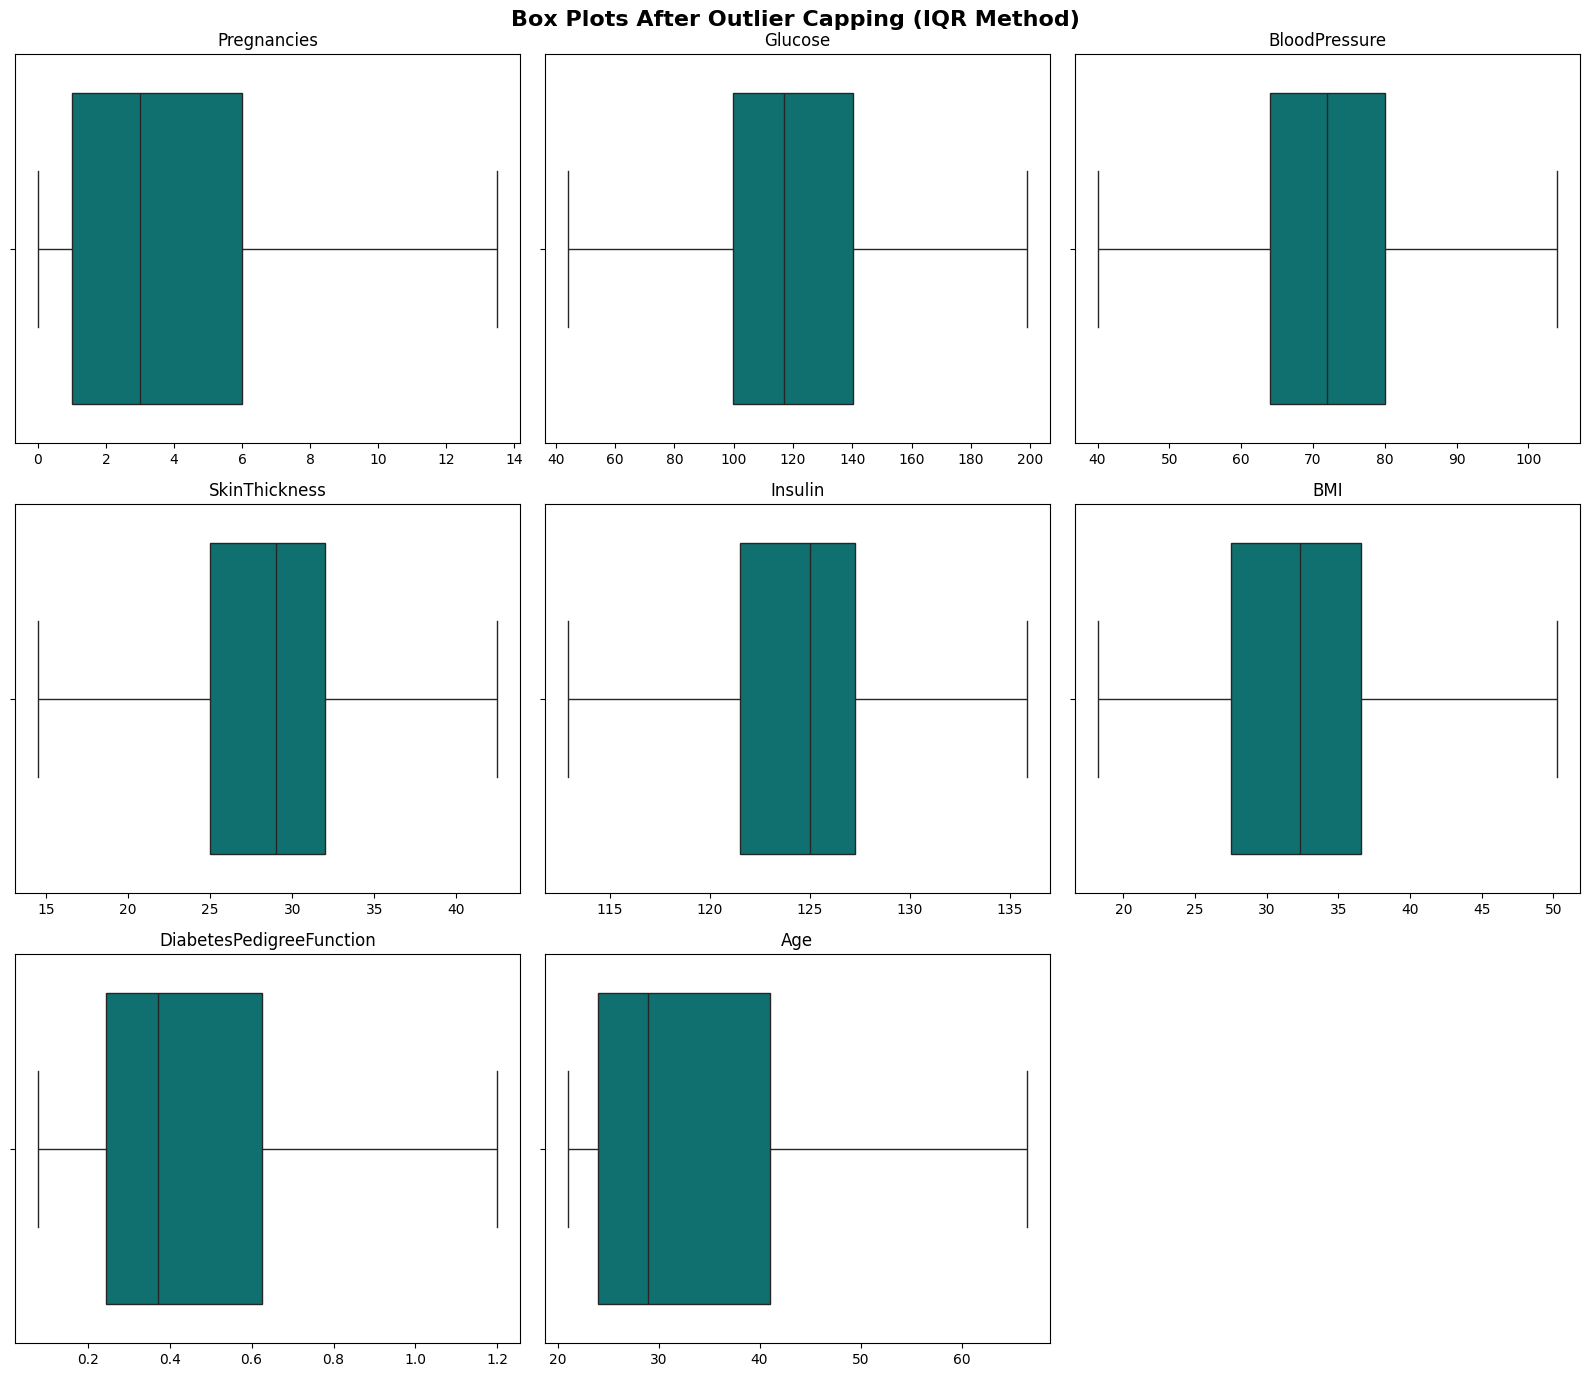

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Box Plots After Outlier Capping (IQR Method)', fontsize=16, fontweight='bold')


axes = axes.flatten()


features = [col for col in df_cleaned.columns if col != 'Outcome']

for i, col in enumerate(features):
    sns.boxplot(data=df_cleaned, x=col, ax=axes[i], color='teal')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [23]:
# 3. Split the data into Features (X) and Target (y)

X = df_cleaned.drop(columns=['Outcome']).values
y = df_cleaned['Outcome'].values

In [24]:
# 4. Train-Test Split

X_train , X_test , y_train, y_test = train_test_split(X , y, test_size=0.2 , random_state=42)

In [25]:
# 5. Feature Scaling using StandardScaler
scaler = StandardScaler()

# Fit and transform training data, transform test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames using the original columns from df_cleaned
X_train_scaled = pd.DataFrame(X_train_scaled, columns=df_cleaned.drop(columns=['Outcome']).columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=df_cleaned.drop(columns=['Outcome']).columns)

X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.528662,-1.256881,-0.020159,0.057034,0.055961,0.002628,-0.531720,-1.046838
1,1.606853,-0.326051,0.833455,-0.606204,0.055961,-0.609888,2.644625,1.513601
2,-0.833735,0.571536,-2.239553,-1.269442,-1.450102,-0.535191,0.709040,-0.958547
3,-1.138809,1.302903,-1.898108,0.057034,0.055961,-1.551070,-0.708971,2.837966
4,0.691632,0.405316,0.662732,1.118215,1.406759,2.079204,-0.765691,1.160437


In [26]:
#title shape of training and testing data
print("shape of X train: ", X_train.shape)
print("shape of X test: ", X_test.shape)

shape of X train:  (614, 8)
shape of X test:  (154, 8)


# **Modele Selection and Training**

In [27]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(n_neighbors=7), 
    'Support Vector Machine (SVM)': SVC(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42), 
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42)
}
models

{'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'K-Nearest Neighbors (KNN)': KNeighborsClassifier(n_neighbors=7),
 'Support Vector Machine (SVM)': SVC(class_weight='balanced', random_state=42),
 'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', max_depth=6, random_state=42)}

In [28]:
list_models_name = []
list_models_accuracy = []
list_models_f1 = []


for name, model in models.items():
    list_models_name.append(name)

    model.fit(X_train_scaled, y_train)
    

    predict = model.predict(X_test_scaled)
    predict_train = model.predict(X_train_scaled)

    acc = accuracy_score(y_test, predict)
    f1 = f1_score(y_test, predict, average='macro')

 
    list_models_accuracy.append(acc * 100)
    list_models_f1.append(f1 * 100)


    print("==================================================================")
    print(name, ": Test Accuracy = ", (acc * 100), "%")
    print(name, ": Train Accuracy = ", (accuracy_score(y_train, predict_train) * 100), "%")
    print("\nClassification Report for Test Data:")
    print(classification_report(y_test, predict))
    print("==================================================================\n")

Logistic Regression : Test Accuracy =  70.77922077922078 %
Logistic Regression : Train Accuracy =  76.71009771986971 %

Classification Report for Test Data:
              precision    recall  f1-score   support

           0       0.83      0.69      0.75        99
           1       0.57      0.75      0.65        55

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.71       154


K-Nearest Neighbors (KNN) : Test Accuracy =  72.72727272727273 %
K-Nearest Neighbors (KNN) : Train Accuracy =  81.59609120521174 %

Classification Report for Test Data:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78        99
           1       0.61      0.65      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154


Support Vector Mac

# **Evaluation**

In [29]:

df_models_accuracy = pd.DataFrame({
    'model_name': list_models_name, 
    'accuracy': list_models_accuracy, 
    'F1': list_models_f1
})


df_models_accuracy = df_models_accuracy.sort_values(by='F1', ascending=False).reset_index(drop=True)


df_models_accuracy

,model_name,accuracy,F1
0,Support Vector Machine (SVM),75.974026,75.323719
1,Random Forest,74.675325,73.744262
2,Decision Tree,74.025974,73.379430
3,K-Nearest Neighbors (KNN),72.727273,70.754205
4,Logistic Regression,70.779221,69.852525


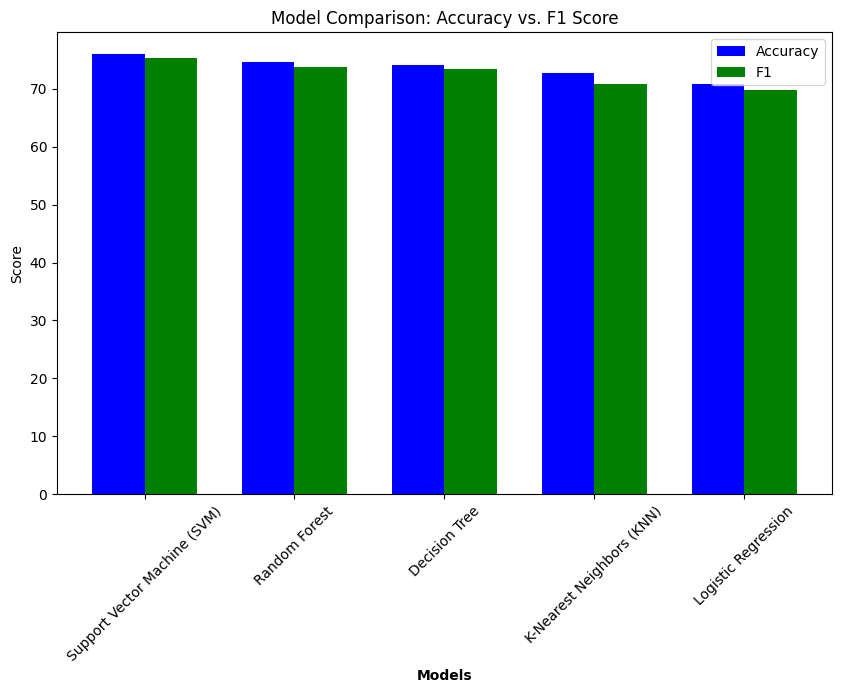

In [30]:
#@title Group bar chart to compare between models by accuracy and f1 score

# Plotting
plt.figure(figsize=(10, 6))

# Bar width
bar_width = 0.35
# Positions of bars on x-axis
r1 = range(len(df_models_accuracy['model_name']))
r2 = [x + bar_width for x in r1]

# Plotting accuracy bars
plt.bar(r1, df_models_accuracy['accuracy'], color='b', width=bar_width, label='Accuracy')

# Plotting F1 bars
plt.bar(r2, df_models_accuracy['F1'], color='g', width=bar_width, label='F1')

# Adding labels
plt.xlabel('Models', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(df_models_accuracy['model_name']))], df_models_accuracy['model_name'])
plt.ylabel('Score')
plt.title('Model Comparison: Accuracy vs. F1 Score')
plt.legend()
plt.xticks(rotation=45)

# Showing plot
plt.show()